# 온라인 쇼핑객 Revenue 예측 - Random Forest 재분석

상위 폴더의 `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`를 사용해 Random Forest를 다시 분석한다.

분석 항목:
- 전처리된 train/test 데이터 로드 및 `PageValues` 누수 컬럼 확인
- IQR 극단값 제거는 민감도 분석으로만 확인하고, 최종 모델은 raw tree 입력 기준으로 평가
- `max_depth`에 따른 과적합 분석
- `gini` 외 `entropy`, `log_loss` criterion 비교
- F1 기준 RandomizedSearchCV 튜닝
- 최종 모델 성능, 혼동 행렬, ROC/PR 곡선, 변수 중요도 확인


In [1]:
%matplotlib inline

from pathlib import Path
import sys
import subprocess
import warnings

modules = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'sklearn': 'scikit-learn',
}
for mod, package in modules.items():
    try:
        __import__(mod)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
)

RANDOM_STATE = 42
plt.rcParams['figure.figsize'] = (8, 4.5)


## 1. 데이터 로드

현재 노트북 위치와 상위 폴더를 탐색해 루트의 전처리 산출물을 읽는다. `PageValues`가 남아 있으면 누수 가능성이 있으므로 제거한다.


In [2]:
def find_data_dir():
    required = ['X_train.csv', 'X_test.csv', 'y_train.csv', 'y_test.csv']
    candidates = []
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidates.extend([
            base / 'csv',
            base / 'models' / 'random_forest' / 'csv',
            base,
        ])
    for base in candidates:
        if all((base / name).exists() for name in required):
            return base
    raise FileNotFoundError('RF용 X/y train/test CSV 파일을 찾지 못했습니다.')

DATA_DIR = find_data_dir()
X_train_raw = pd.read_csv(DATA_DIR / 'X_train.csv')
X_test_raw = pd.read_csv(DATA_DIR / 'X_test.csv')
y_train = pd.read_csv(DATA_DIR / 'y_train.csv').iloc[:, 0].astype(int).reset_index(drop=True)
y_test = pd.read_csv(DATA_DIR / 'y_test.csv').iloc[:, 0].astype(int).reset_index(drop=True)

leakage_cols = [col for col in ['PageValues'] if col in X_train_raw.columns]
X_train = X_train_raw.drop(columns=leakage_cols).reset_index(drop=True)
X_test = X_test_raw.drop(columns=leakage_cols).reset_index(drop=True)

print(f'Data directory: {DATA_DIR}')
print(f'Train: {X_train.shape}, positive ratio: {y_train.mean():.4f}')
print(f'Test : {X_test.shape}, positive ratio: {y_test.mean():.4f}')
print(f'Removed leakage columns: {leakage_cols if leakage_cols else "None"}')
print(f'Feature count: {X_train.shape[1]}')
X_train.head()


Data directory: /Users/hyunkim/2026_2/datamining/shopper-prediction/models/random_forest/csv
Train: (9764, 31), positive ratio: 0.1563
Test : (2441, 31), positive ratio: 0.1565
Removed leakage columns: None
Feature count: 31


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,SpecialDay,OperatingSystems,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,8,203.6,1,0.0,42,1052.400000,0.0,0.004545,0.0,2,...,0,0,0,0,1,0,0,0,0,1
1,0,0.0,0,0.0,30,901.288889,0.0,0.007333,0.0,2,...,0,0,0,0,0,0,0,1,0,0
2,0,0.0,0,0.0,13,421.166667,0.0,0.028205,0.8,1,...,0,0,0,1,0,0,0,0,0,1
3,2,40.0,0,0.0,5,558.500000,0.0,0.028571,0.0,2,...,0,0,1,0,0,0,0,1,0,0
4,0,0.0,0,0.0,16,1599.266667,0.0,0.013333,0.0,4,...,0,0,0,1,0,0,0,0,0,1


## 2. IQR 민감도 분석용 극단값 제거

다른 모델과의 비교 일관성을 위해 최종 Random Forest는 극단값을 제거하지 않은 raw tree 입력을 기본으로 사용한다. 아래 IQR 기준 데이터는 행 제거가 성능과 표본 구성에 미치는 영향을 확인하는 민감도 분석용으로만 둔다.


In [3]:
OUTLIER_CANDIDATES = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'SpecialDay',
    'total_pages', 'total_duration', 'avg_time_per_product', 'bounce_exit_ratio',
]
outlier_cols = [col for col in OUTLIER_CANDIDATES if col in X_train.columns]

q1 = X_train[outlier_cols].quantile(0.25)
q3 = X_train[outlier_cols].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
active_outlier_cols = iqr[iqr > 0].index.tolist()

def inlier_mask(X):
    if not active_outlier_cols:
        return pd.Series(True, index=X.index)
    return ((X[active_outlier_cols] >= lower[active_outlier_cols]) &
            (X[active_outlier_cols] <= upper[active_outlier_cols])).all(axis=1)

train_mask = inlier_mask(X_train)
test_mask = inlier_mask(X_test)

X_train_clean = X_train.loc[train_mask].reset_index(drop=True)
y_train_clean = y_train.loc[train_mask].reset_index(drop=True)
X_test_clean = X_test.loc[test_mask].reset_index(drop=True)
y_test_clean = y_test.loc[test_mask].reset_index(drop=True)

removed_train = len(X_train) - len(X_train_clean)
removed_test = len(X_test) - len(X_test_clean)
print(f'Outlier columns: {active_outlier_cols}')
print(f'Train removed: {removed_train:,} / {len(X_train):,} ({removed_train / len(X_train):.2%})')
print(f'Test removed : {removed_test:,} / {len(X_test):,} ({removed_test / len(X_test):.2%})')
print(f'Clean train: {X_train_clean.shape}, positive ratio: {y_train_clean.mean():.4f}')
print(f'Clean test : {X_test_clean.shape}, positive ratio: {y_test_clean.mean():.4f}')


Outlier columns: ['Administrative', 'Administrative_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'total_pages', 'total_duration', 'avg_time_per_product', 'bounce_exit_ratio']
Train removed: 3,303 / 9,764 (33.83%)
Test removed : 813 / 2,441 (33.31%)
Clean train: (6461, 31), positive ratio: 0.1568
Clean test : (1628, 31), positive ratio: 0.1548


## 3. 평가 함수

불균형 분류이므로 Accuracy만 보지 않고 Precision, Recall, F1, ROC-AUC, PR-AUC를 함께 본다.


In [4]:
def evaluate_model(name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_eval)[:, 1]
    else:
        y_prob = y_pred
    return {
        'model': name,
        'accuracy': accuracy_score(y_eval, y_pred),
        'precision': precision_score(y_eval, y_pred, zero_division=0),
        'recall': recall_score(y_eval, y_pred, zero_division=0),
        'f1': f1_score(y_eval, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_eval, y_prob),
        'pr_auc': average_precision_score(y_eval, y_prob),
    }


## 4. 깊이에 따른 과적합 분석

Random Forest는 여러 Decision Tree를 평균/투표로 묶는 모델이지만, 각 트리가 너무 깊어지면 학습 데이터의 우연한 세부 패턴까지 외울 수 있다. 초반 분기는 많은 샘플이 공유하는 큰 패턴을 잡지만, 깊은 분기는 데이터가 더 잘게 쪼개지면서 몇 개 안 되는 샘플의 조합까지 규칙처럼 만든다. 이 경우 train F1은 계속 올라가지만 처음 보는 validation/test 데이터에서는 같은 규칙이 재현되지 않아 성능이 떨어진다.

그래서 여기서는 원래 train 데이터를 다시 80:20으로 나누어 train 내부 validation split을 만들었다. 이 validation은 최종 test가 아니다. 최종 test를 반복해서 들여다보며 모델을 고르는 일을 막기 위한 내부 점검용이다. `stratify=y_train`을 사용해 구매/비구매 비율을 유지했기 때문에, 불균형 분류에서도 깊이 변화의 영향을 비교하는 용도로 유효하다.

해석 기준은 단순하다. 깊이가 깊어질수록 train F1만 크게 오르고 validation F1이 정체되거나 하락하면 과적합 신호다. 반대로 validation F1이 함께 개선되는 구간은 모델이 더 유용한 패턴을 학습한 구간으로 볼 수 있다.


Raw train validation split summary
                 set  rows  purchase_count  purchase_ratio
     raw depth train  7811            1221          0.1563
raw depth validation  1953             305          0.1562

Raw train validation depth result:
max_depth  train_f1  val_f1  train_accuracy  val_accuracy
        2    0.3815  0.3698          0.5933        0.5812
        4    0.4035  0.3813          0.6340        0.6196
        6    0.4390  0.3953          0.6822        0.6539
        8    0.5082  0.4048          0.7492        0.6974
       10    0.5962  0.4164          0.8132        0.7373
       12    0.6946  0.4036          0.8715        0.7624
       16    0.8675  0.3523          0.9534        0.8080
     None    0.9639  0.2911          0.9885        0.8254

Raw train validation F1 기준 최적 깊이: 10 (val_f1=0.4164, train_f1=0.5962)

Clean train validation depth result 참고:
max_depth  train_f1  val_f1  train_accuracy  val_accuracy
        2    0.3670  0.3847          0.6062        0.6265
  

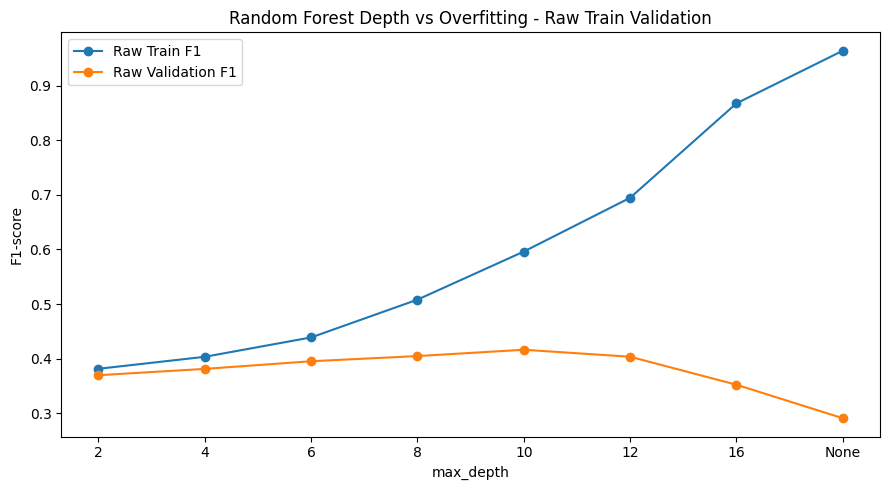

In [5]:
X_raw_tr, X_raw_val, y_raw_tr, y_raw_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

X_clean_tr, X_clean_val, y_clean_tr, y_clean_val = train_test_split(
    X_train_clean,
    y_train_clean,
    test_size=0.2,
    stratify=y_train_clean,
    random_state=RANDOM_STATE,
)

# 기존 criterion 비교 셀 호환용 변수. 이제 raw validation 기준을 기본으로 둔다.
X_tr, X_val, y_tr, y_val = X_raw_tr, X_raw_val, y_raw_tr, y_raw_val

depth_candidates = [2, 4, 6, 8, 10, 12, 16, None]

def run_depth_analysis(label, X_fit, X_validate, y_fit, y_validate):
    rows = []
    for depth in depth_candidates:
        model = RandomForestClassifier(
            n_estimators=200,
            criterion='gini',
            max_depth=depth,
            min_samples_leaf=3,
            max_features='sqrt',
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        model.fit(X_fit, y_fit)
        rows.append({
            'evaluation_set': label,
            'max_depth': 'None' if depth is None else depth,
            'train_f1': f1_score(y_fit, model.predict(X_fit)),
            'val_f1': f1_score(y_validate, model.predict(X_validate)),
            'train_accuracy': accuracy_score(y_fit, model.predict(X_fit)),
            'val_accuracy': accuracy_score(y_validate, model.predict(X_validate)),
        })
    return pd.DataFrame(rows)

depth_result_raw = run_depth_analysis('raw train validation', X_raw_tr, X_raw_val, y_raw_tr, y_raw_val)
depth_result_clean = run_depth_analysis('clean train validation', X_clean_tr, X_clean_val, y_clean_tr, y_clean_val)

# 기존 변수명은 raw validation 기준 결과를 가리키도록 유지한다.
depth_result = depth_result_raw
best_depth_row = depth_result_raw.loc[depth_result_raw['val_f1'].idxmax()]
best_depth_row_clean = depth_result_clean.loc[depth_result_clean['val_f1'].idxmax()]

print('Raw train validation split summary')
print(pd.DataFrame([
    {'set': 'raw depth train', 'rows': len(y_raw_tr), 'purchase_count': int(y_raw_tr.sum()), 'purchase_ratio': y_raw_tr.mean()},
    {'set': 'raw depth validation', 'rows': len(y_raw_val), 'purchase_count': int(y_raw_val.sum()), 'purchase_ratio': y_raw_val.mean()},
]).round(4).to_string(index=False))
print('\nRaw train validation depth result:')
print(depth_result_raw.round(4).drop(columns=['evaluation_set']).to_string(index=False))
print(f"\nRaw train validation F1 기준 최적 깊이: {best_depth_row['max_depth']} "
      f"(val_f1={best_depth_row['val_f1']:.4f}, train_f1={best_depth_row['train_f1']:.4f})")

print('\nClean train validation depth result 참고:')
print(depth_result_clean.round(4).drop(columns=['evaluation_set']).to_string(index=False))
print(f"\nClean train validation F1 기준 최적 깊이: {best_depth_row_clean['max_depth']} "
      f"(val_f1={best_depth_row_clean['val_f1']:.4f}, train_f1={best_depth_row_clean['train_f1']:.4f})")

plot_depth_raw = depth_result_raw.copy()
plot_depth_raw['depth_label'] = plot_depth_raw['max_depth'].astype(str)
plt.figure(figsize=(9, 5))
plt.plot(plot_depth_raw['depth_label'], plot_depth_raw['train_f1'], marker='o', label='Raw Train F1')
plt.plot(plot_depth_raw['depth_label'], plot_depth_raw['val_f1'], marker='o', label='Raw Validation F1')
plt.xlabel('max_depth')
plt.ylabel('F1-score')
plt.title('Random Forest Depth vs Overfitting - Raw Train Validation')
plt.legend()
plt.tight_layout()
plt.show()


## 5. criterion 비교

Random Forest의 `criterion`은 `gini` 외에 `entropy`, `log_loss`를 사용할 수 있다. 현재 설치된 scikit-learn에서 지원되는 criterion만 후보로 사용한다.


In [6]:
def supported_criteria(criteria):
    ok = []
    sample_X = X_train.head(100)
    sample_y = y_train.head(100)
    for criterion in criteria:
        try:
            RandomForestClassifier(
                n_estimators=5,
                criterion=criterion,
                random_state=RANDOM_STATE,
            ).fit(sample_X, sample_y)
            ok.append(criterion)
        except ValueError:
            pass
    return ok

criteria = supported_criteria(['gini', 'entropy', 'log_loss'])
criterion_rows = []
for criterion in criteria:
    model = RandomForestClassifier(
        n_estimators=200,
        criterion=criterion,
        max_depth=best_depth_row['max_depth'] if best_depth_row['max_depth'] != 'None' else None,
        min_samples_leaf=3,
        max_features='sqrt',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_tr, y_tr)
    criterion_rows.append(evaluate_model(criterion, model, X_val, y_val))

criterion_result = pd.DataFrame(criterion_rows).sort_values('f1', ascending=False)
print(f'Criterion candidates: {criteria}')
criterion_result.round(4)


Criterion candidates: ['gini', 'entropy', 'log_loss']


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,gini,0.7373,0.3188,0.6000,0.4164,0.7580,0.3427
1,entropy,0.7286,0.3128,0.6164,0.4150,0.7587,0.3453
2,log_loss,0.7286,0.3128,0.6164,0.4150,0.7587,0.3453


## 6. 하이퍼파라미터 튜닝

F1을 기준으로 `criterion`, `max_depth`, `min_samples_leaf`, `min_samples_split`, `max_features`, `n_estimators`를 탐색한다.


In [7]:
param_distributions = {
    'n_estimators': [150, 250, 350],
    'criterion': criteria,
    'max_depth': [4, 6, 8, 10, 12, None],
    'min_samples_split': [2, 10, 30, 50],
    'min_samples_leaf': [1, 3, 5, 10, 20],
    'max_features': ['sqrt', 'log2'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def run_rf_search(scoring, label):
    search = RandomizedSearchCV(
        estimator=RandomForestClassifier(
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        param_distributions=param_distributions,
        n_iter=60,
        scoring=scoring,
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        return_train_score=True,
    )
    search.fit(X_train, y_train)

    result_df = pd.DataFrame(search.cv_results_).sort_values('rank_test_score')
    summary_cols = [
        'rank_test_score', 'mean_test_score', 'std_test_score', 'mean_train_score',
        'param_n_estimators', 'param_criterion', 'param_max_depth',
        'param_min_samples_leaf', 'param_min_samples_split', 'param_max_features',
    ]
    print(f'Best params - {label}:')
    print(search.best_params_)
    print(f"Best CV {label}: {search.best_score_:.4f}")
    print(f'\nTop 10 tuning results - {label}:')
    print(result_df[summary_cols].head(10).round(4).to_string(index=False))
    print('\n' + '-' * 80 + '\n')
    return search, result_df

f1_search, f1_cv_result = run_rf_search('f1', 'F1')
precision_search, precision_cv_result = run_rf_search('precision', 'Precision')


Best params - F1:
{'n_estimators': 250, 'min_samples_split': 50, 'min_samples_leaf': 3, 'max_features': 'log2', 'max_depth': 12, 'criterion': 'log_loss'}
Best CV F1: 0.4314

Top 10 tuning results - F1:
 rank_test_score  mean_test_score  std_test_score  mean_train_score  param_n_estimators param_criterion param_max_depth  param_min_samples_leaf  param_min_samples_split param_max_features
               1           0.4314          0.0179            0.5586                 250        log_loss              12                       3                       50               log2
               2           0.4309          0.0160            0.5530                 150         entropy              12                       5                       50               log2
               3           0.4282          0.0135            0.4978                 250         entropy              10                      20                        2               log2
               4           0.4275          0.0

Best params - Precision:
{'n_estimators': 250, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2', 'max_depth': None, 'criterion': 'entropy'}
Best CV Precision: 0.4356

Top 10 tuning results - Precision:
 rank_test_score  mean_test_score  std_test_score  mean_train_score  param_n_estimators param_criterion param_max_depth  param_min_samples_leaf  param_min_samples_split param_max_features
               1           0.4356          0.0258            0.9415                 250         entropy            None                       3                        2               log2
               2           0.4322          0.0203            0.9266                 350            gini            None                       3                        2               log2
               3           0.3713          0.0125            0.6454                 350            gini            None                       1                       30               log2
               4         

## 7. 최종 모델 평가

튜닝된 모델을 극단값 제거 없이 raw train 전체에 학습한 결과를 메인 test 성능으로 확인한다. IQR 제거 데이터는 비교용으로만 함께 출력한다.


In [8]:
default_model = RandomForestClassifier(
    n_estimators=200,
    criterion='gini',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
default_model.fit(X_train, y_train)

best_f1_model = f1_search.best_estimator_
best_precision_model = precision_search.best_estimator_

# 기존 분석 셀과 호환되도록 F1 기준 모델을 기본 tuned 모델로 둔다.
best_model = best_f1_model

def prediction_bundle(model, X_eval):
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]
    return y_pred, y_prob

# Raw test: 기존 stratified split의 전체 test 데이터에서 PageValues만 제거한 메인 평가 데이터
# Clean test: IQR 극단값 제거 후 남은 민감도 분석용 평가 데이터
y_pred_f1, y_prob_f1 = prediction_bundle(best_f1_model, X_test_clean)
y_pred_precision, y_prob_precision = prediction_bundle(best_precision_model, X_test_clean)
y_pred_f1_raw, y_prob_f1_raw = prediction_bundle(best_f1_model, X_test)
y_pred_precision_raw, y_prob_precision_raw = prediction_bundle(best_precision_model, X_test)

# 기존 변수명은 raw test의 F1 기준 tuned model을 가리키도록 유지한다.
y_pred = y_pred_f1_raw
y_prob = y_prob_f1_raw

print('Evaluation set summary')
print(pd.DataFrame([
    {'set': 'raw test', 'rows': len(y_test), 'purchase_count': int(y_test.sum()), 'purchase_ratio': y_test.mean()},
    {'set': 'clean test', 'rows': len(y_test_clean), 'purchase_count': int(y_test_clean.sum()), 'purchase_ratio': y_test_clean.mean()},
]).round(4).to_string(index=False))

metrics_clean = pd.DataFrame([
    evaluate_model('Random Forest default', default_model, X_test_clean, y_test_clean),
    evaluate_model('Random Forest tuned by F1', best_f1_model, X_test_clean, y_test_clean),
    evaluate_model('Random Forest tuned by Precision', best_precision_model, X_test_clean, y_test_clean),
])
metrics_clean.insert(1, 'evaluation_set', 'clean test')

metrics_raw = pd.DataFrame([
    evaluate_model('Random Forest default', default_model, X_test, y_test),
    evaluate_model('Random Forest tuned by F1', best_f1_model, X_test, y_test),
    evaluate_model('Random Forest tuned by Precision', best_precision_model, X_test, y_test),
])
metrics_raw.insert(1, 'evaluation_set', 'raw test')

# 기존 변수명은 raw test 기준 표를 가리키도록 유지한다.
metrics = metrics_raw

print('\nClean test metrics:')
print(metrics_clean.round(4).to_string(index=False))
print('\nRaw test metrics:')
print(metrics_raw.round(4).to_string(index=False))

print('\nClassification report - F1 tuned model (clean test):')
print(classification_report(y_test_clean, y_pred_f1, target_names=['No Purchase', 'Purchase'], zero_division=0))
print('\nClassification report - F1 tuned model (raw test):')
print(classification_report(y_test, y_pred_f1_raw, target_names=['No Purchase', 'Purchase'], zero_division=0))
print('Best F1-tuned params:')
print(f1_search.best_params_)

print('\nClassification report - Precision tuned model (clean test):')
print(classification_report(y_test_clean, y_pred_precision, target_names=['No Purchase', 'Purchase'], zero_division=0))
print('\nClassification report - Precision tuned model (raw test):')
print(classification_report(y_test, y_pred_precision_raw, target_names=['No Purchase', 'Purchase'], zero_division=0))
print('Best Precision-tuned params:')
print(precision_search.best_params_)


Evaluation set summary
       set  rows  purchase_count  purchase_ratio
  raw test  2441             382          0.1565
clean test  1628             252          0.1548



Clean test metrics:
                           model evaluation_set  accuracy  precision  recall     f1  roc_auc  pr_auc
           Random Forest default     clean test    0.8458     0.5200  0.0516 0.0939   0.7479  0.3328
       Random Forest tuned by F1     clean test    0.7340     0.3095  0.5833 0.4044   0.7628  0.3537
Random Forest tuned by Precision     clean test    0.8397     0.4634  0.2262 0.3040   0.7657  0.3495

Raw test metrics:
                           model evaluation_set  accuracy  precision  recall     f1  roc_auc  pr_auc
           Random Forest default       raw test    0.8431     0.4932  0.0942 0.1582   0.7734  0.3543
       Random Forest tuned by F1       raw test    0.7370     0.3253  0.6335 0.4298   0.7826  0.3578
Random Forest tuned by Precision       raw test    0.8345     0.4534  0.2801 0.3463   0.7860  0.3635

Classification report - F1 tuned model (clean test):
              precision    recall  f1-score   support

 No Purchase       0.91      0.76      0.83

## 8. 혼동 행렬, ROC/PR 곡선, 변수 중요도

그래프는 파일로 저장하지 않고 노트북 출력으로만 확인한다.


Raw test confusion matrices
F1 tuned confusion matrix


,Pred No Purchase,Pred Purchase
Actual No Purchase,1557,502
Actual Purchase,140,242


Precision tuned confusion matrix


,Pred No Purchase,Pred Purchase
Actual No Purchase,1930,129
Actual Purchase,275,107


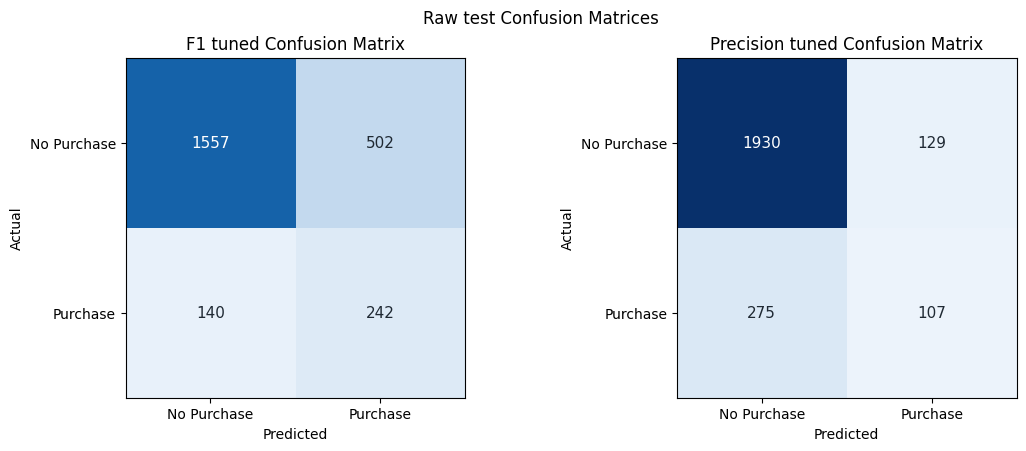

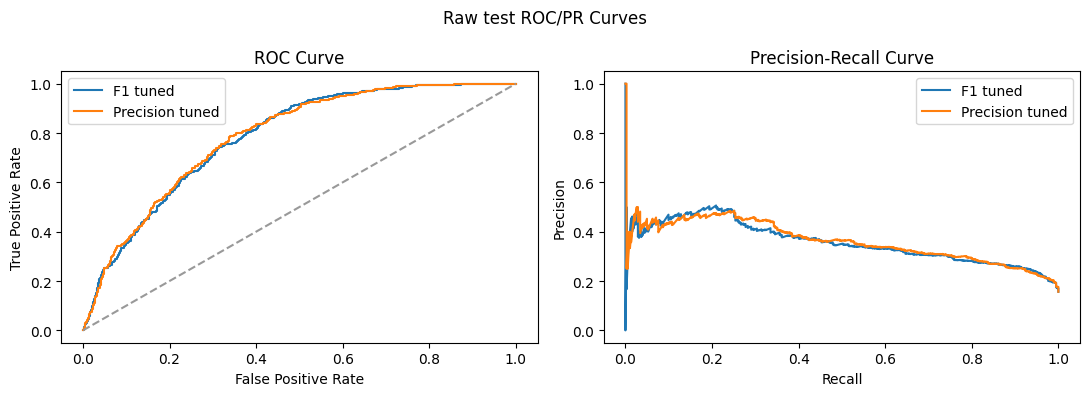

F1 tuned top 15 feature importance


,model,feature,importance
7,F1 tuned,ExitRates,0.1411
15,F1 tuned,total_duration,0.0950
5,F1 tuned,ProductRelated_Duration,0.0912
6,F1 tuned,BounceRates,0.0813
16,F1 tuned,avg_time_per_product,0.0724
14,F1 tuned,total_pages,0.0643
4,F1 tuned,ProductRelated,0.0593
1,F1 tuned,Administrative_Duration,0.0481
0,F1 tuned,Administrative,0.0454
17,F1 tuned,bounce_exit_ratio,0.0416


Precision tuned top 15 feature importance


,model,feature,importance
7,Precision tuned,ExitRates,0.1191
15,Precision tuned,total_duration,0.0901
5,Precision tuned,ProductRelated_Duration,0.0898
16,Precision tuned,avg_time_per_product,0.0855
14,Precision tuned,total_pages,0.0705
4,Precision tuned,ProductRelated,0.0677
6,Precision tuned,BounceRates,0.0603
1,Precision tuned,Administrative_Duration,0.0582
0,Precision tuned,Administrative,0.0454
17,Precision tuned,bounce_exit_ratio,0.0453


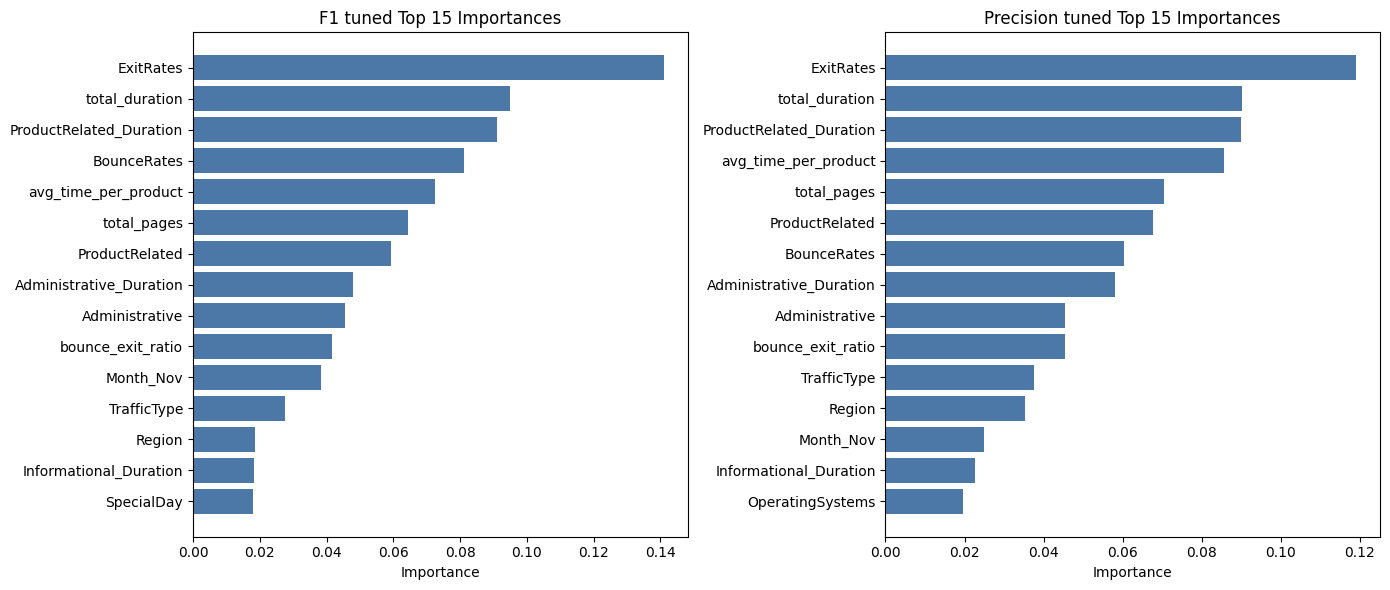

In [9]:
model_outputs_clean = {
    'F1 tuned': {
        'model': best_f1_model,
        'y_pred': y_pred_f1,
        'y_prob': y_prob_f1,
    },
    'Precision tuned': {
        'model': best_precision_model,
        'y_pred': y_pred_precision,
        'y_prob': y_prob_precision,
    },
}

model_outputs_raw = {
    'F1 tuned': {
        'model': best_f1_model,
        'y_pred': y_pred_f1_raw,
        'y_prob': y_prob_f1_raw,
    },
    'Precision tuned': {
        'model': best_precision_model,
        'y_pred': y_pred_precision_raw,
        'y_prob': y_prob_precision_raw,
    },
}

# 이후 feature importance 셀과의 호환을 위해 모델 출력 기본값은 raw test 기준으로 둔다.
model_outputs = model_outputs_raw

def display_confusion_tables(label, outputs, y_eval):
    print(f'{label} confusion matrices')
    for name, output in outputs.items():
        cm = confusion_matrix(y_eval, output['y_pred'])
        confusion = pd.DataFrame(
            cm,
            index=['Actual No Purchase', 'Actual Purchase'],
            columns=['Pred No Purchase', 'Pred Purchase'],
        )
        print(f'{name} confusion matrix')
        display(confusion)

def plot_confusion_matrices(label, outputs, y_eval):
    matrices = {
        name: confusion_matrix(y_eval, output['y_pred'])
        for name, output in outputs.items()
    }
    max_count = max(cm.max() for cm in matrices.values())
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)
    fig.suptitle(f'{label} Confusion Matrices')
    for ax, (name, cm) in zip(axes, matrices.items()):
        ax.imshow(cm, cmap='Blues', vmin=0, vmax=max_count)
        ax.set_xticks([0, 1], ['No Purchase', 'Purchase'])
        ax.set_yticks([0, 1], ['No Purchase', 'Purchase'])
        for row in range(cm.shape[0]):
            for col in range(cm.shape[1]):
                value = cm[row, col]
                text_color = 'white' if value > max_count * 0.55 else '#1f2933'
                ax.text(col, row, str(value), ha='center', va='center', color=text_color, fontsize=11)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        ax.set_title(f'{name} Confusion Matrix')
    plt.show()
    return matrices

def plot_roc_pr_curves(label, outputs, y_eval):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    fig.suptitle(label)
    for name, output in outputs.items():
        fpr, tpr, _ = roc_curve(y_eval, output['y_prob'])
        precision, recall, _ = precision_recall_curve(y_eval, output['y_prob'])
        axes[0].plot(fpr, tpr, label=name)
        axes[1].plot(recall, precision, label=name)
    axes[0].plot([0, 1], [0, 1], linestyle='--', color='#999999')
    axes[0].set_title('ROC Curve')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].legend()
    axes[1].set_title('Precision-Recall Curve')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

display_confusion_tables('Raw test', model_outputs_raw, y_test)
confusion_matrices_raw = plot_confusion_matrices(
    'Raw test',
    model_outputs_raw,
    y_test,
)
plot_roc_pr_curves(
    'Raw test ROC/PR Curves',
    model_outputs_raw,
    y_test,
)

# 기존 변수명은 raw test 기준 혼동행렬을 가리키도록 유지한다.
confusion_matrices = confusion_matrices_raw

importance_tables = []
for name, output in model_outputs.items():
    importance = (
        pd.DataFrame({
            'model': name,
            'feature': X_train.columns,
            'importance': output['model'].feature_importances_,
        })
        .sort_values('importance', ascending=False)
    )
    importance_tables.append(importance)
    print(f'{name} top 15 feature importance')
    display(importance.head(15).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, importance in zip(axes, importance_tables):
    name = importance['model'].iloc[0]
    plot_df = importance.head(15).sort_values('importance')
    ax.barh(plot_df['feature'], plot_df['importance'], color='#4c78a8')
    ax.set_title(f'{name} Top 15 Importances')
    ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

feature_importance = importance_tables[0].drop(columns=['model'])


## 9. K-Means 군집 정보를 활용한 RF feature 융합

이 섹션의 목적은 기존 Random Forest에 K-Means가 만든 행동 유형 정보를 추가했을 때 예측력이 좋아지는지 확인하는 것이다. 여기서 말하는 융합은 두 모델의 예측값을 평균내거나 투표로 섞은 것이 아니라, K-Means가 만든 정보를 RF의 새로운 입력 feature로 붙이는 방식이다.

진행 방식은 다음과 같다. 먼저 기존 `X_train`, `X_test`, `y_train`, `y_test` split은 그대로 둔다. 그다음 K-Means는 train 데이터의 행동 변수 11개만 보고 fit한다. test 데이터는 train에서 학습된 scaler와 K-Means 중심을 이용해 `predict`와 `transform`만 수행한다. 이렇게 해야 test 분포가 군집 중심 학습에 새어 들어가지 않는다.

실제로 추가된 feature는 두 종류다. 첫 번째는 cluster label one-hot이다. 예를 들어 어떤 세션이 cluster 2에 속하면 `rf_cluster_2=1`, `rf_cluster_0=0`, `rf_cluster_1=0`처럼 표시된다. 두 번째는 각 세션이 세 군집 중심에서 얼마나 떨어져 있는지를 나타내는 `rf_cluster_dist_0`, `rf_cluster_dist_1`, `rf_cluster_dist_2`다. label은 "어느 군집인가"를 알려주고, distance는 "그 군집 패턴에 얼마나 전형적으로 가까운가"를 알려준다.

비교 모델은 세 가지다. 첫째, 기존 F1 tuned RF. 둘째, K-Means cluster label을 `rf_cluster_0`, `rf_cluster_1`, `rf_cluster_2` one-hot 컬럼으로 추가한 RF. 셋째, one-hot에 더해 `rf_cluster_dist_0~2`까지 추가한 RF다. 세 모델은 같은 F1 tuned RF 하이퍼파라미터를 사용하므로, 차이는 cluster feature 추가 여부에서 온다.


K-Means train-only clustering profile
 cluster  rows  purchase_count  purchase_ratio
       0  7207            1093          0.1517
       1  1851             430          0.2323
       2   706               3          0.0042

K-Means behavior feature columns
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'SpecialDay', 'Weekend', 'is_new_visitor']

Feature matrix shapes
                     matrix  train_columns  test_columns
                   baseline             31            31
            cluster one-hot             34            34
cluster one-hot + distances             37            37



Raw test fusion metrics:
                          model  accuracy  precision  recall     f1  roc_auc  pr_auc
        RF baseline tuned by F1    0.7370     0.3253  0.6335 0.4298   0.7826  0.3578
            RF + KMeans one-hot    0.7362     0.3253  0.6387 0.4311   0.7838  0.3623
RF + KMeans one-hot + distances    0.7329     0.3171  0.6126 0.4179   0.7809  0.3556

RF baseline tuned by F1 top 15 feature importance


,model,feature,importance
0,RF baseline tuned by F1,ExitRates,0.1411
1,RF baseline tuned by F1,total_duration,0.0950
2,RF baseline tuned by F1,ProductRelated_Duration,0.0912
3,RF baseline tuned by F1,BounceRates,0.0813
4,RF baseline tuned by F1,avg_time_per_product,0.0724
5,RF baseline tuned by F1,total_pages,0.0643
6,RF baseline tuned by F1,ProductRelated,0.0593
7,RF baseline tuned by F1,Administrative_Duration,0.0481
8,RF baseline tuned by F1,Administrative,0.0454
9,RF baseline tuned by F1,bounce_exit_ratio,0.0416



RF + KMeans one-hot top 15 feature importance


,model,feature,importance
0,RF + KMeans one-hot,ExitRates,0.1555
1,RF + KMeans one-hot,ProductRelated_Duration,0.0957
2,RF + KMeans one-hot,total_duration,0.0843
3,RF + KMeans one-hot,BounceRates,0.0754
4,RF + KMeans one-hot,avg_time_per_product,0.0731
5,RF + KMeans one-hot,total_pages,0.0584
6,RF + KMeans one-hot,ProductRelated,0.0579
7,RF + KMeans one-hot,Administrative_Duration,0.0485
8,RF + KMeans one-hot,bounce_exit_ratio,0.0417
9,RF + KMeans one-hot,Administrative,0.0415



RF + KMeans one-hot + distances top 15 feature importance


,model,feature,importance
0,RF + KMeans one-hot + distances,ExitRates,0.1271
1,RF + KMeans one-hot + distances,rf_cluster_dist_2,0.1028
2,RF + KMeans one-hot + distances,ProductRelated_Duration,0.0775
3,RF + KMeans one-hot + distances,total_duration,0.0729
4,RF + KMeans one-hot + distances,avg_time_per_product,0.0589
5,RF + KMeans one-hot + distances,rf_cluster_dist_1,0.0585
6,RF + KMeans one-hot + distances,BounceRates,0.0517
7,RF + KMeans one-hot + distances,ProductRelated,0.0478
8,RF + KMeans one-hot + distances,rf_cluster_dist_0,0.0459
9,RF + KMeans one-hot + distances,total_pages,0.0425



Cluster-derived feature importance


,model,feature,importance
53,RF + KMeans one-hot,rf_cluster_2,0.0096
58,RF + KMeans one-hot,rf_cluster_0,0.0047
59,RF + KMeans one-hot,rf_cluster_1,0.0039
66,RF + KMeans one-hot + distances,rf_cluster_dist_2,0.1028
70,RF + KMeans one-hot + distances,rf_cluster_dist_1,0.0585
73,RF + KMeans one-hot + distances,rf_cluster_dist_0,0.0459
90,RF + KMeans one-hot + distances,rf_cluster_2,0.0058
95,RF + KMeans one-hot + distances,rf_cluster_0,0.0033
99,RF + KMeans one-hot + distances,rf_cluster_1,0.0016


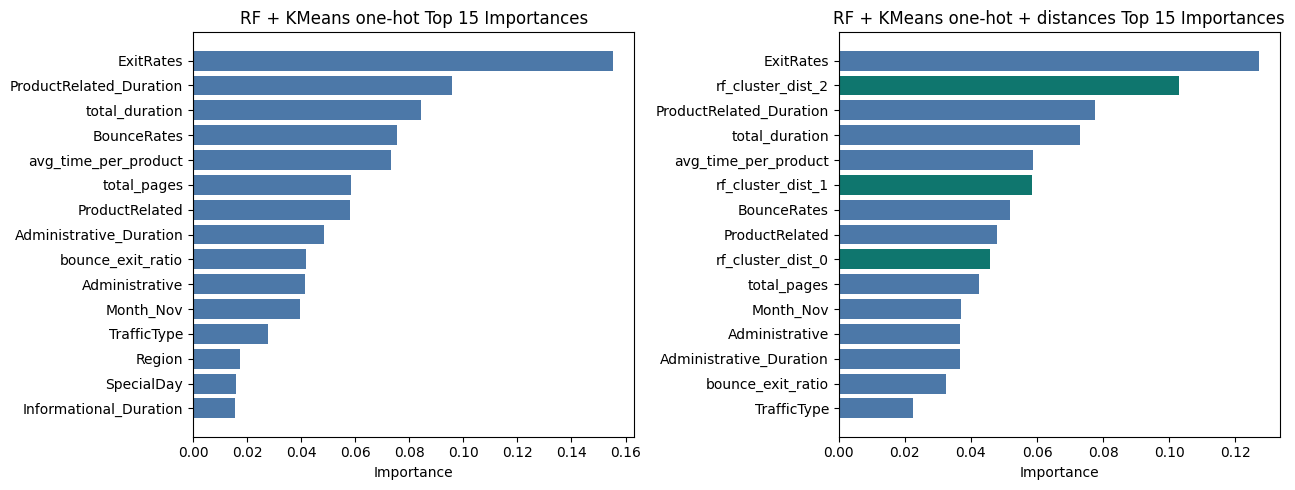

In [10]:
KMEANS_K = 3
KMEANS_FEATURES = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'SpecialDay',
    'Weekend', 'is_new_visitor',
]
KMEANS_LOG_COLS = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'SpecialDay',
]

def make_kmeans_behavior_frame(X):
    behavior = X[[col for col in KMEANS_FEATURES if col in X.columns and col != 'is_new_visitor']].copy()
    if 'is_new_visitor' in X.columns:
        behavior['is_new_visitor'] = X['is_new_visitor'].astype(int)
    elif 'VisitorType_New_Visitor' in X.columns:
        behavior['is_new_visitor'] = X['VisitorType_New_Visitor'].astype(int)
    else:
        behavior['is_new_visitor'] = 0
    return behavior[KMEANS_FEATURES]

def transform_kmeans_behavior_frame(X, fitted_scaler=None):
    behavior = make_kmeans_behavior_frame(X)
    behavior_log = behavior.copy()
    behavior_log[KMEANS_LOG_COLS] = np.log1p(behavior_log[KMEANS_LOG_COLS])
    if fitted_scaler is None:
        fitted_scaler = StandardScaler().fit(behavior_log)
    return fitted_scaler.transform(behavior_log), fitted_scaler, behavior

X_train_kmeans_scaled, kmeans_scaler, X_train_kmeans_behavior = transform_kmeans_behavior_frame(X_train)
X_test_kmeans_scaled, _, X_test_kmeans_behavior = transform_kmeans_behavior_frame(X_test, kmeans_scaler)

kmeans = KMeans(n_clusters=KMEANS_K, random_state=RANDOM_STATE, n_init=10)
with warnings.catch_warnings():
    # sklearn 1.6 + numpy 2 can emit harmless k-means++ matmul RuntimeWarnings
    # on finite scaled data. Keep notebook output focused on the experiment results.
    warnings.filterwarnings('ignore', category=RuntimeWarning, module='sklearn')
    train_cluster_labels = kmeans.fit_predict(X_train_kmeans_scaled)
    test_cluster_labels = kmeans.predict(X_test_kmeans_scaled)
    train_cluster_distances = kmeans.transform(X_train_kmeans_scaled)
    test_cluster_distances = kmeans.transform(X_test_kmeans_scaled)

cluster_columns = [f'rf_cluster_{idx}' for idx in range(KMEANS_K)]
distance_columns = [f'rf_cluster_dist_{idx}' for idx in range(KMEANS_K)]

def make_cluster_feature_frame(labels, distances=None, include_distances=False):
    label_series = pd.Series(labels, name='rf_cluster')
    one_hot = pd.get_dummies(label_series, prefix='rf_cluster').astype(int)
    one_hot = one_hot.reindex(columns=cluster_columns, fill_value=0)
    if not include_distances:
        return one_hot.reset_index(drop=True)

    distance_frame = pd.DataFrame(distances, columns=distance_columns)
    return pd.concat(
        [one_hot.reset_index(drop=True), distance_frame.reset_index(drop=True)],
        axis=1,
    )

train_cluster_features = make_cluster_feature_frame(train_cluster_labels)
test_cluster_features = make_cluster_feature_frame(test_cluster_labels)
train_cluster_distance_features = make_cluster_feature_frame(
    train_cluster_labels,
    train_cluster_distances,
    include_distances=True,
)
test_cluster_distance_features = make_cluster_feature_frame(
    test_cluster_labels,
    test_cluster_distances,
    include_distances=True,
)

X_train_cluster = pd.concat(
    [X_train.reset_index(drop=True), train_cluster_features],
    axis=1,
)
X_test_cluster = pd.concat(
    [X_test.reset_index(drop=True), test_cluster_features],
    axis=1,
)
X_train_cluster_distance = pd.concat(
    [X_train.reset_index(drop=True), train_cluster_distance_features],
    axis=1,
)
X_test_cluster_distance = pd.concat(
    [X_test.reset_index(drop=True), test_cluster_distance_features],
    axis=1,
)

cluster_profile = (
    pd.DataFrame({'cluster': train_cluster_labels, 'Revenue': y_train})
    .groupby('cluster')
    .agg(rows=('Revenue', 'size'), purchase_count=('Revenue', 'sum'), purchase_ratio=('Revenue', 'mean'))
    .reset_index()
    .sort_values('cluster')
)

print('K-Means train-only clustering profile')
print(cluster_profile.round(4).to_string(index=False))
print('\nK-Means behavior feature columns')
print(KMEANS_FEATURES)
print('\nFeature matrix shapes')
print(pd.DataFrame([
    {'matrix': 'baseline', 'train_columns': X_train.shape[1], 'test_columns': X_test.shape[1]},
    {'matrix': 'cluster one-hot', 'train_columns': X_train_cluster.shape[1], 'test_columns': X_test_cluster.shape[1]},
    {'matrix': 'cluster one-hot + distances', 'train_columns': X_train_cluster_distance.shape[1], 'test_columns': X_test_cluster_distance.shape[1]},
]).to_string(index=False))

def make_f1_tuned_rf():
    params = f1_search.best_params_.copy()
    return RandomForestClassifier(
        **params,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

cluster_model = make_f1_tuned_rf()
cluster_model.fit(X_train_cluster, y_train)

cluster_distance_model = make_f1_tuned_rf()
cluster_distance_model.fit(X_train_cluster_distance, y_train)

fusion_metrics = pd.DataFrame([
    evaluate_model('RF baseline tuned by F1', best_f1_model, X_test, y_test),
    evaluate_model('RF + KMeans one-hot', cluster_model, X_test_cluster, y_test),
    evaluate_model('RF + KMeans one-hot + distances', cluster_distance_model, X_test_cluster_distance, y_test),
])

print('\nRaw test fusion metrics:')
print(fusion_metrics.round(4).to_string(index=False))

fusion_outputs = {
    'RF baseline tuned by F1': {
        'model': best_f1_model,
        'X_eval': X_test,
        'feature_names': list(X_train.columns),
    },
    'RF + KMeans one-hot': {
        'model': cluster_model,
        'X_eval': X_test_cluster,
        'feature_names': list(X_train_cluster.columns),
    },
    'RF + KMeans one-hot + distances': {
        'model': cluster_distance_model,
        'X_eval': X_test_cluster_distance,
        'feature_names': list(X_train_cluster_distance.columns),
    },
}

fusion_importance_tables = []
for name, output in fusion_outputs.items():
    importance = (
        pd.DataFrame({
            'model': name,
            'feature': output['feature_names'],
            'importance': output['model'].feature_importances_,
        })
        .sort_values('importance', ascending=False)
        .reset_index(drop=True)
    )
    fusion_importance_tables.append(importance)
    print(f'\n{name} top 15 feature importance')
    display(importance.head(15).round(4))

fusion_importance = pd.concat(fusion_importance_tables, ignore_index=True)
cluster_feature_importance = fusion_importance[
    fusion_importance['feature'].str.startswith('rf_cluster')
].sort_values(['model', 'importance'], ascending=[True, False])

print('\nCluster-derived feature importance')
display(cluster_feature_importance.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_models = [
    ('RF + KMeans one-hot', cluster_model, X_train_cluster.columns),
    ('RF + KMeans one-hot + distances', cluster_distance_model, X_train_cluster_distance.columns),
]
for ax, (name, model, columns) in zip(axes, plot_models):
    plot_df = (
        pd.DataFrame({'feature': columns, 'importance': model.feature_importances_})
        .sort_values('importance', ascending=False)
        .head(15)
        .sort_values('importance')
    )
    colors = ['#0f766e' if feature.startswith('rf_cluster') else '#4c78a8' for feature in plot_df['feature']]
    ax.barh(plot_df['feature'], plot_df['importance'], color=colors)
    ax.set_title(f'{name} Top 15 Importances')
    ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


### 9.1 융합 실험 해석

K-Means train-only profile을 보면 cluster 2는 구매율이 0.42%로 매우 낮고, cluster 1은 23.23%로 평균보다 높다. 즉 군집 번호는 단순한 번호가 아니라 방문 행동 패턴에 따른 구매 성향 차이를 요약한다. 이 정보가 RF에 추가되면 RF는 개별 변수뿐 아니라 "이 세션이 어떤 행동 유형에 속하는지"도 함께 볼 수 있다.

어떤 부분이 발전했나? `RF + KMeans one-hot`은 baseline보다 F1이 0.4298에서 0.4311로, Recall이 0.6335에서 0.6387로, PR-AUC가 0.3578에서 0.3623으로 소폭 올랐다. 개선 폭은 크지 않지만, 구매자를 놓치지 않는 방향으로 약간 발전했다. cluster 2처럼 구매율이 거의 없는 군집과 cluster 1처럼 구매율이 높은 군집이 구분되면, RF는 비슷한 ExitRates나 체류 시간을 가진 세션 사이에서도 행동 맥락을 조금 더 세밀하게 나눌 수 있다.

따라서 cluster label은 주 예측 변수를 대체하는 강한 변수라기보다, 행동 유형을 요약해 주는 보조 feature로 해석하는 것이 적절하다. 핵심 변수는 여전히 `ExitRates`, `ProductRelated_Duration`, `total_duration` 같은 원래 RF feature다.

반면 `RF + KMeans one-hot + distances`는 distance feature 중요도가 높게 나타났지만 F1과 Recall은 baseline보다 낮아졌다. 거리 feature가 train 데이터의 세부 구조를 더 강하게 설명했지만 test 일반화에는 오히려 불리했을 가능성이 있다. 따라서 최종 해석에서는 one-hot cluster feature만 추가한 모델을 가장 합리적인 융합 후보로 본다.
